In [1]:
# Step 1: Data Consolidation
# Load all 11 seasons of EPL match data (2015–2026) from football-data.co.uk, retain relevant statistical columns, and sort chronologically.

In [3]:
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# 1. Grab all Premier League files
all_files = glob.glob("E0*.csv")
if len(all_files) == 0:
    raise FileNotFoundError("No E0*.csv files found.")

df_list = [pd.read_csv(file, encoding='latin1', on_bad_lines='skip') for file in all_files]
master_df = pd.concat(df_list, axis=0, ignore_index=True)

# 2. Keep the important feature
columns_to_keep = [
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'HS', 'AS', 'HST', 'AST', 'HC', 'AC'
]
df_clean = master_df[[col for col in columns_to_keep if col in master_df.columns]].copy()

# 3. Standardize and sort chronological
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, format='mixed')
df_clean = df_clean.sort_values(by='Date').reset_index(drop=True)
df_clean = df_clean.dropna(subset=['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']).copy()

print(f"Rows: {len(df_clean)}")

Rows: 291


In [4]:
# Step 2: EWMA Feature Engineering
# Compute Exponentially Weighted Moving Average (EWMA) team strength features
# using a strict extract-before-update pattern to prevent data leakage.
# Season boundaries are detected using a get_season() function to reset EWMA
# at the start of each new campaign.

In [5]:
ALPHA = 0.1
team_ewma = {}

# Feature lists
h_scored, h_conceded, h_sot_for, h_sot_against = [], [], [], []
a_scored, a_conceded, a_sot_for, a_sot_against = [], [], [], []

def get_season(date):
    if date.month >= 7:
        return date.year
    else:
        return date.year - 1

def update_ewma(current_ewma, new_value):
    if pd.isna(current_ewma): return new_value
    return (ALPHA * new_value) + ((1 - ALPHA) * current_ewma)

for index, row in df_clean.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    current_season = get_season(row['Date'])

    # Initialise team state if first time seen
    if home not in team_ewma:
        team_ewma[home] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}
    if away not in team_ewma:
        team_ewma[away] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}

    # SEASON RESET -> triggers on first match of a new season, regardless of month
    if team_ewma[home]['last_season'] != current_season:
        team_ewma[home] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}
    if team_ewma[away]['last_season'] != current_season:
        team_ewma[away] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}

    # EXTRACT N-1 STATE
    h_scored.append(team_ewma[home]['scored'])
    h_conceded.append(team_ewma[home]['conceded'])
    h_sot_for.append(team_ewma[home]['sot_for'])
    h_sot_against.append(team_ewma[home]['sot_against'])

    a_scored.append(team_ewma[away]['scored'])
    a_conceded.append(team_ewma[away]['conceded'])
    a_sot_for.append(team_ewma[away]['sot_for'])
    a_sot_against.append(team_ewma[away]['sot_against'])

    # UPDATE STATE WITH CURRENT MATCH RESULT
    team_ewma[home]['scored']      = update_ewma(team_ewma[home]['scored'], row['FTHG'])
    team_ewma[home]['conceded']    = update_ewma(team_ewma[home]['conceded'], row['FTAG'])
    team_ewma[home]['sot_for']     = update_ewma(team_ewma[home]['sot_for'], row['HST'])
    team_ewma[home]['sot_against'] = update_ewma(team_ewma[home]['sot_against'], row['AST'])

    team_ewma[away]['scored']      = update_ewma(team_ewma[away]['scored'], row['FTAG'])
    team_ewma[away]['conceded']    = update_ewma(team_ewma[away]['conceded'], row['FTHG'])
    team_ewma[away]['sot_for']     = update_ewma(team_ewma[away]['sot_for'], row['AST'])
    team_ewma[away]['sot_against'] = update_ewma(team_ewma[away]['sot_against'], row['HST'])

    # UPDATE SEASON TRACKER
    team_ewma[home]['last_season'] = current_season
    team_ewma[away]['last_season'] = current_season

# Assign to dataframe
df_clean['H_AvgScored'], df_clean['H_AvgConceded'] = h_scored, h_conceded
df_clean['H_AvgSOT'], df_clean['H_AvgSOT_Conceded'] = h_sot_for, h_sot_against
df_clean['A_AvgScored'], df_clean['A_AvgConceded'] = a_scored, a_conceded
df_clean['A_AvgSOT'], df_clean['A_AvgSOT_Conceded'] = a_sot_for, a_sot_against

# Drop only rows where EWMA features are NaN (i.e. each team's first match of a season)
ewma_feature_cols = [
    'H_AvgScored', 'H_AvgConceded', 'H_AvgSOT', 'H_AvgSOT_Conceded',
    'A_AvgScored', 'A_AvgConceded', 'A_AvgSOT', 'A_AvgSOT_Conceded'
]
df_model = df_clean.dropna(subset=ewma_feature_cols).reset_index(drop=True)
print(f"After targeted EWMA NaN drop: {len(df_model)} rows")

# TARGET-SPECIFIC FEATURES
# Intermediate columns are computed inline and dropped immediately after —
# only the final net dominance features are retained in df_model

# Goals matchup — symmetric
goals_diff_home = df_model['H_AvgScored'] - df_model['A_AvgConceded']
goals_diff_away = df_model['A_AvgScored'] - df_model['H_AvgConceded']
df_model['Net_Goal_Dominance'] = goals_diff_home - goals_diff_away

# SOT matchup — symmetric
sot_diff_home = df_model['H_AvgSOT'] - df_model['A_AvgSOT_Conceded']
sot_diff_away = df_model['A_AvgSOT'] - df_model['H_AvgSOT_Conceded']
df_model['Net_SOT_Dominance'] = sot_diff_home - sot_diff_away

# Aggregate intensity features
df_model['Total_Attacking_Intensity'] = df_model['H_AvgSOT'] + df_model['A_AvgSOT']
df_model['Total_Defensive_Fragility'] = df_model['H_AvgSOT_Conceded'] + df_model['A_AvgSOT_Conceded']

After targeted EWMA NaN drop: 281 rows


In [6]:
# ================================================================
# HEAD-TO-HEAD WIN RATE — Matchup-Specific History
# ================================================================
# Captures whether the home team has historically dominated this
# specific opponent, regardless of current form. Some teams
# consistently underperform against certain opponents due to
# tactical or psychological factors that EWMA cannot capture.
#
# LEAKAGE NOTE: For match N between Team A (home) vs Team B (away),
# we only use results from matches strictly BEFORE match N's date.
# The current match is never included in its own H2H calculation.

# Sort chronologically to ensure strict past-only lookup
df_h2h_source = df_clean.sort_values('Date').copy()

# We'll compute H2H win rate for each match by iterating chronologically
# and maintaining a running record of past meetings per matchup
h2h_records = {}  # key: (HomeTeam, AwayTeam), value: [wins, total]

h2h_home_winrate = []

for _, row in df_h2h_source.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    key = (home, away)

    # Extract PAST record before this match
    if key not in h2h_records:
        h2h_records[key] = {'home_wins': 0, 'total': 0}

    past = h2h_records[key]

    if past['total'] == 0:
        # No prior meetings — use overall home win rate as neutral prior
        h2h_home_winrate.append(np.nan)
    else:
        h2h_home_winrate.append(past['home_wins'] / past['total'])

    # NOW update with current match result (after extracting)
    past['total'] += 1
    if row['FTR'] == 'H':
        past['home_wins'] += 1

# Assign to source dataframe
df_h2h_source['H2H_HomeWinRate'] = h2h_home_winrate

# Merge into df_model
df_model = df_model.merge(
    df_h2h_source[['Date', 'HomeTeam', 'AwayTeam', 'H2H_HomeWinRate']],
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

# Fill NaN (first-ever meeting between two teams) with overall home win rate
overall_home_winrate = (df_clean['FTR'] == 'H').mean()
df_model['H2H_HomeWinRate'] = df_model['H2H_HomeWinRate'].fillna(overall_home_winrate)

print(f"Head-to-Head Win Rate — sample stats:")
print(f"  Overall home win rate (used as prior): {overall_home_winrate:.3f}")
print(f"  H2H feature mean: {df_model['H2H_HomeWinRate'].mean():.3f}")
print(f"  H2H feature min:  {df_model['H2H_HomeWinRate'].min():.3f}")
print(f"  H2H feature max:  {df_model['H2H_HomeWinRate'].max():.3f}")
print(f"  NaN check: {df_model['H2H_HomeWinRate'].isna().sum()}")
print(f"\nMatches with no prior H2H history (filled with prior):")
print(f"  {(df_h2h_source['H2H_HomeWinRate'].isna()).sum()} matches out of {len(df_h2h_source)}")

Head-to-Head Win Rate — sample stats:
  Overall home win rate (used as prior): 0.423
  H2H feature mean: 0.423
  H2H feature min:  0.423
  H2H feature max:  0.423
  NaN check: 0

Matches with no prior H2H history (filled with prior):
  291 matches out of 291


In [7]:
## Step 3: ALPHA Sensitivity Analysis
# Select the optimal EWMA decay factor (α) using TimeSeriesSplit cross-validation
# on the training set only. Evaluated using 3-class log-loss to match the actual
# modelling task.

  ALPHA=0.10 (≈19-game window) → Mean CV Log-Loss: 1.1317
  ALPHA=0.20 (≈9-game window) → Mean CV Log-Loss: 1.1398
  ALPHA=0.33 (≈5-game window) → Mean CV Log-Loss: 1.1471
  ALPHA=0.50 (≈3-game window) → Mean CV Log-Loss: 1.1396


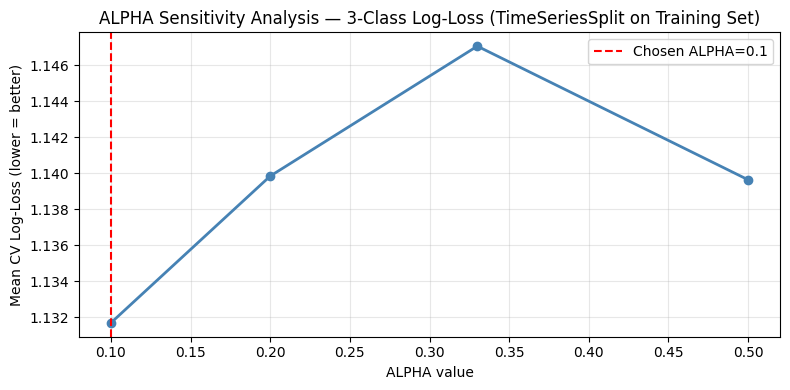


Best ALPHA from 3-class CV: 0.1
Chosen ALPHA: 0.1
Conclusion: Chosen ALPHA is confirmed optimal by 3-class CV.


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

def build_ewma_features(df, alpha):
    """Rebuild EWMA features for a given alpha value."""
    team_ewma = {}
    h_scored, h_conceded, h_sot_for, h_sot_against = [], [], [], []
    a_scored, a_conceded, a_sot_for, a_sot_against = [], [], [], []

    def get_season(date):
        return date.year if date.month >= 7 else date.year - 1

    def update_ewma(current, new):
        if pd.isna(current): return new
        return (alpha * new) + ((1 - alpha) * current)

    for _, row in df.iterrows():
        home, away = row['HomeTeam'], row['AwayTeam']
        current_season = get_season(row['Date'])

        for team in [home, away]:
            if team not in team_ewma:
                team_ewma[team] = {'scored': np.nan, 'conceded': np.nan,
                                   'sot_for': np.nan, 'sot_against': np.nan,
                                   'last_season': current_season}
            if team_ewma[team]['last_season'] != current_season:
                team_ewma[team] = {'scored': np.nan, 'conceded': np.nan,
                                   'sot_for': np.nan, 'sot_against': np.nan,
                                   'last_season': current_season}

        h_scored.append(team_ewma[home]['scored'])
        h_conceded.append(team_ewma[home]['conceded'])
        h_sot_for.append(team_ewma[home]['sot_for'])
        h_sot_against.append(team_ewma[home]['sot_against'])
        a_scored.append(team_ewma[away]['scored'])
        a_conceded.append(team_ewma[away]['conceded'])
        a_sot_for.append(team_ewma[away]['sot_for'])
        a_sot_against.append(team_ewma[away]['sot_against'])

        team_ewma[home]['scored']      = update_ewma(team_ewma[home]['scored'], row['FTHG'])
        team_ewma[home]['conceded']    = update_ewma(team_ewma[home]['conceded'], row['FTAG'])
        team_ewma[home]['sot_for']     = update_ewma(team_ewma[home]['sot_for'], row['HST'])
        team_ewma[home]['sot_against'] = update_ewma(team_ewma[home]['sot_against'], row['AST'])
        team_ewma[away]['scored']      = update_ewma(team_ewma[away]['scored'], row['FTAG'])
        team_ewma[away]['conceded']    = update_ewma(team_ewma[away]['conceded'], row['FTHG'])
        team_ewma[away]['sot_for']     = update_ewma(team_ewma[away]['sot_for'], row['AST'])
        team_ewma[away]['sot_against'] = update_ewma(team_ewma[away]['sot_against'], row['HST'])
        team_ewma[home]['last_season'] = current_season
        team_ewma[away]['last_season'] = current_season

    result = df.copy()
    result['H_AvgScored'], result['H_AvgConceded'] = h_scored, h_conceded
    result['H_AvgSOT'],    result['H_AvgSOT_Conceded'] = h_sot_for, h_sot_against
    result['A_AvgScored'], result['A_AvgConceded'] = a_scored, a_conceded
    result['A_AvgSOT'],    result['A_AvgSOT_Conceded'] = a_sot_for, a_sot_against

    ewma_cols = ['H_AvgScored','H_AvgConceded','H_AvgSOT','H_AvgSOT_Conceded',
                 'A_AvgScored','A_AvgConceded','A_AvgSOT','A_AvgSOT_Conceded']
    result = result.dropna(subset=ewma_cols).reset_index(drop=True)

    goals_diff_home = result['H_AvgScored'] - result['A_AvgConceded']
    goals_diff_away = result['A_AvgScored'] - result['H_AvgConceded']
    result['Net_Goal_Dominance'] = goals_diff_home - goals_diff_away

    sot_diff_home = result['H_AvgSOT'] - result['A_AvgSOT_Conceded']
    sot_diff_away = result['A_AvgSOT'] - result['H_AvgSOT_Conceded']
    result['Net_SOT_Dominance'] = sot_diff_home - sot_diff_away
    result['Total_Attacking_Intensity'] = result['H_AvgSOT'] + result['A_AvgSOT']
    result['Total_Defensive_Fragility'] = result['H_AvgSOT_Conceded'] + result['A_AvgSOT_Conceded']
    return result

# Candidate ALPHA values
# ALPHA = 2/(N+1) → 0.10≈N19, 0.20≈N9, 0.33≈N5, 0.50≈N3
alpha_candidates = [0.10, 0.20, 0.33, 0.50]
features_for_cv = [
    'Net_Goal_Dominance',
    'Net_SOT_Dominance',
    'Total_Attacking_Intensity',
    'Total_Defensive_Fragility'
]

# Use only training portion of df_clean to avoid test set contamination
split_index_clean = int(len(df_clean) * 0.8)
df_train_clean = df_clean.iloc[:split_index_clean].copy()

tscv = TimeSeriesSplit(n_splits=5)
alpha_results = {}

le_cv = LabelEncoder()

for alpha in alpha_candidates:
    df_alpha = build_ewma_features(df_train_clean, alpha)
    X = df_alpha[features_for_cv].values

    # ✅ FIXED: 3-class target (A=0, D=1, H=2) — matches the actual modelling task
    y = le_cv.fit_transform(df_alpha['FTR'])

    fold_scores = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        sc = StandardScaler()
        X_tr  = sc.fit_transform(X_tr)
        X_val = sc.transform(X_val)

        # Multiclass logistic regression — consistent with actual modelling task
        # Scored with log_loss: measures calibration quality across all 3 classes
        # Lower log_loss = better probability estimates (consistent with RPS philosophy)
        clf = LogisticRegression(
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )
        clf.fit(X_tr, y_tr)
        y_val_proba = clf.predict_proba(X_val)

        # Use negative log_loss so that higher = better (consistent with CV convention)
        fold_scores.append(-log_loss(y_val, y_val_proba))

    alpha_results[alpha] = np.mean(fold_scores)
    equiv_n = round((2 / alpha) - 1)
    print(f"  ALPHA={alpha:.2f} (≈{equiv_n}-game window) → Mean CV Log-Loss: {-np.mean(fold_scores):.4f}")

# Plot
plt.figure(figsize=(8, 4))
# Negate back for plotting so lower = better is visually clear
plot_values = [-v for v in alpha_results.values()]
plt.plot(list(alpha_results.keys()), plot_values,
         marker='o', linewidth=2, color='steelblue')
plt.axvline(x=ALPHA, color='red', linestyle='--', label=f'Chosen ALPHA={ALPHA}')
plt.xlabel('ALPHA value')
plt.ylabel('Mean CV Log-Loss (lower = better)')
plt.title('ALPHA Sensitivity Analysis — 3-Class Log-Loss (TimeSeriesSplit on Training Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Report best alpha
best_alpha = min(alpha_results, key=lambda a: -alpha_results[a])  # min log-loss
print(f"\nBest ALPHA from 3-class CV: {best_alpha}")
print(f"Chosen ALPHA: {ALPHA}")
if best_alpha == ALPHA:
    print("Conclusion: Chosen ALPHA is confirmed optimal by 3-class CV.")
else:
    print(f"Conclusion: 3-class CV suggests ALPHA={best_alpha} may be marginally better.")
    print(f"Note: If the log-loss difference is small (<0.005), ALPHA={ALPHA} remains defensible.")

In [9]:
## Step 4: Elo Integration & Target Engineering
# Fetch live ClubElo ratings via API and merge using merge_asof (backward
# time-safe join) to avoid future data leakage. Engineer prediction targets
# for both 1X2 match result and Over/Under 2.5 goals.

In [11]:
import time
from sklearn.preprocessing import LabelEncoder, StandardScaler

elo_map = {
    'Arsenal': 'Arsenal',
    'Aston Villa': 'Aston Villa',
    'Bournemouth': 'Bournemouth',
    'Brentford': 'Brentford',
    'Brighton': 'Brighton',
    'Burnley': 'Burnley',
    'Cardiff': 'Cardiff',
    'Chelsea': 'Chelsea',
    'Crystal Palace': 'Crystal Palace',
    'Everton': 'Everton',
    'Fulham': 'Fulham',
    'Huddersfield': 'Huddersfield',
    'Hull': 'Hull',
    'Ipswich': 'Ipswich',
    'Leeds': 'Leeds',
    'Leicester': 'Leicester',
    'Liverpool': 'Liverpool',
    'Luton': 'Luton',
    'Man City': 'Man City',
    'Man United': 'Man United',
    'Middlesbrough': 'Middlesbrough',
    'Newcastle': 'Newcastle',
    'Norwich': 'Norwich',
    "Nott'm Forest": 'Forest',
    'QPR': 'QPR',
    'Sheff United': 'Sheffield United',
    'Sheffield United': 'Sheffield United',
    'Southampton': 'Southampton',
    'Spurs': 'Tottenham',
    'Stoke': 'Stoke',
    'Sunderland': 'Sunderland',
    'Swansea': 'Swansea',
    'Watford': 'Watford',
    'West Brom': 'West Brom',
    'West Ham': 'West Ham',
    'Wolves': 'Wolves'
}

df_model['Home_Elo_Name'] = df_model['HomeTeam'].map(elo_map).fillna(df_model['HomeTeam'])
df_model['Away_Elo_Name'] = df_model['AwayTeam'].map(elo_map).fillna(df_model['AwayTeam'])
unique_teams = pd.concat([df_model['Home_Elo_Name'], df_model['Away_Elo_Name']]).unique()

elo_df_list = []
for team in unique_teams:
    try:
        clean_team = str(team).replace(" ", "")
        url = f"http://api.clubelo.com/{clean_team}"
        team_elo = pd.read_csv(url)[['Club', 'From', 'Elo']]
        elo_df_list.append(team_elo)
        time.sleep(0.2)
    except Exception as e:
        print(f"Warning: Could not fetch Elo for {team}.")

all_elo_df = pd.concat(elo_df_list, ignore_index=True)
all_elo_df['From'] = pd.to_datetime(all_elo_df['From'])
all_elo_df = all_elo_df.sort_values('From')

df_model = pd.merge_asof(df_model, all_elo_df.rename(columns={'Elo': 'Home_Elo', 'Club': 'Home_Club'}),
                         left_on='Date', right_on='From', left_by='Home_Elo_Name', right_by='Home_Club', direction='backward')
df_model = pd.merge_asof(df_model, all_elo_df.rename(columns={'Elo': 'Away_Elo', 'Club': 'Away_Club'}),
                         left_on='Date', right_on='From', left_by='Away_Elo_Name', right_by='Away_Club', direction='backward')

df_model['Elo_Diff'] = df_model['Home_Elo'] - df_model['Away_Elo']
df_model = df_model.dropna(subset=['Home_Elo', 'Away_Elo']).reset_index(drop=True)

# Target engineering — needed before EDA so we can plot Target_OU
df_model['Total_Goals'] = df_model['FTHG'] + df_model['FTAG']
df_model['Target_OU'] = (df_model['Total_Goals'] > 2.5).astype(int)

le = LabelEncoder()
df_model['Target_1X2'] = le.fit_transform(df_model['FTR'])  # A=0, D=1, H=2

features = [
    'Net_Goal_Dominance',
    'Net_SOT_Dominance',
    'Total_Attacking_Intensity',
    'Total_Defensive_Fragility',
    'Elo_Diff',
    'H2H_HomeWinRate',
]

print(f"df_model ready for EDA. Rows: {len(df_model)}")

KeyboardInterrupt: 

In [ ]:
## Step 5: Exploratory Data Analysis (Pre-Split)
# Visualise feature distributions and their relationship with match outcomes
# using the full prepared dataset before any train/test split.

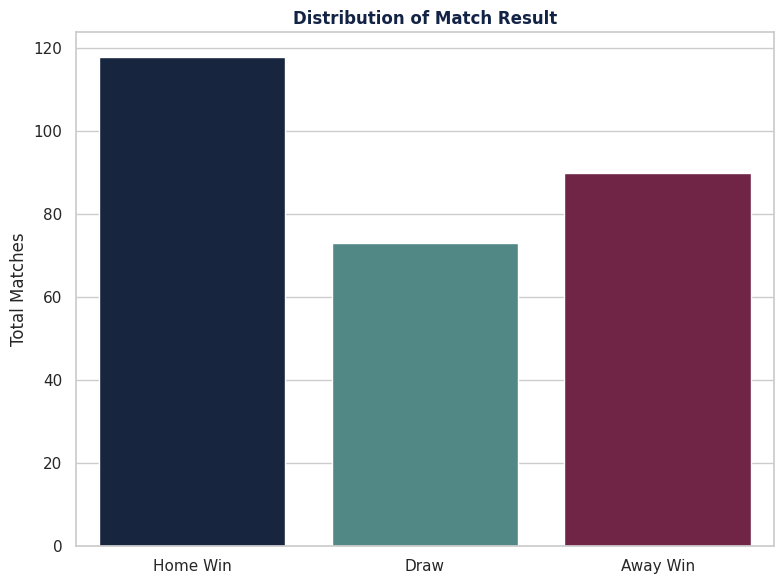

ValueError: Could not interpret value `Target_OU` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the poster-themed colors
navy_blue = "#122345"
muted_teal = "#48918d"
dark_maroon = "#7d1844"
dusty_mauve = "#d8c8d3"

# Define the custom palettes
palette_hda = {'H': navy_blue, 'D': muted_teal, 'A': dark_maroon}
palette_ou = ['#607c8e', '#6b4c65']

# 2. Set theme (whitegrid)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ==========================================
# PLOT 1 — Match Result Distribution
# ==========================================
plt.figure(figsize=(8, 6))
ax1 = sns.countplot(data=df_model, x='FTR', order=['H', 'D', 'A'], palette=palette_hda)
ax1.set_title('Distribution of Match Result', color=navy_blue, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Total Matches')
ax1.set_xticklabels(['Home Win', 'Draw', 'Away Win'])
ax1.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot1_match_results.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show() # Display the plot, then close it to start the next one fresh

# ==========================================
# PLOT 2 — Attacking Intensity vs O/U
# ==========================================
plt.figure(figsize=(8, 6))
ax2 = sns.boxplot(data=df_model, x='Target_OU', y='Total_Attacking_Intensity',
                  palette=palette_ou, width=0.4,
                  medianprops={'color': 'white', 'linewidth': 1})
ax2.set_title('Attacking Intensity in Over/Under 2.5 Matches', color=navy_blue, fontweight='bold')
ax2.set_xlabel('Total Match Goals')
ax2.set_ylabel('Recent Attacking Intensity (Shots on Target)')
ax2.set_xticklabels(['0-2 Goals (Under 2.5)', '3+ Goals (Over 2.5)'])
ax2.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot2_attacking_intensity.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 3 — Net Goal Dominance vs Result
# ==========================================
plt.figure(figsize=(8, 6))
ax3 = sns.boxplot(data=df_model, x='FTR', y='Net_Goal_Dominance', order=['H', 'D', 'A'],
                  palette=palette_hda, medianprops={'color': 'white', 'linewidth': 1})
ax3.set_title('Net Goal Dominance on Match Result', color=navy_blue, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Net Goal Dominance (Home - Away)')
ax3.set_xticklabels(['Home Win', 'Draw', 'Away Win'])
ax3.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot3_goal_dominance.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 4 — Elo Differential vs Result
# ==========================================
plt.figure(figsize=(8, 6))
ax4 = sns.boxplot(data=df_model, x='FTR', y='Elo_Diff', order=['H', 'D', 'A'],
                  palette=palette_hda, medianprops={'color': 'white', 'linewidth': 1})
ax4.set_title('Elo Score Difference on Match Result', color=navy_blue, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Elo Score Difference (Home - Away)')
ax4.set_xticklabels(['Home Win', 'Draw', 'Away Win'])
ax4.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot4_elo_difference.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# Descriptive stats on full dataset
# ==========================================
draw_pct = (df_model['FTR'] == 'D').mean() * 100
print(f"Percentage of Draws: {draw_pct:.1f}%")
print(f"Average Attacking Intensity in 'Over 2.5' games: {df_model[df_model['Target_OU']==1]['Total_Attacking_Intensity'].mean():.2f}")
print(f"Average Attacking Intensity in 'Under 2.5' games: {df_model[df_model['Target_OU']==0]['Total_Attacking_Intensity'].mean():.2f}")

In [ ]:
## Step 6: Train/Test Split & Standardisation
# Apply an 80/20 chronological split — oldest 80% for training, newest 20%
# for testing. StandardScaler fitted exclusively on training data to prevent
# test set statistics from influencing feature scaling.

In [13]:
# 80/20 Chronological Split
split_index = int(len(df_model) * 0.8)
df_train = df_model.iloc[:split_index].copy()
df_test = df_model.iloc[split_index:].copy()

X_train, X_test = df_train[features], df_test[features]
y_ou_train, y_ou_test = df_train['Target_OU'], df_test['Target_OU']
y_1x2_train, y_1x2_test = df_train['Target_1X2'], df_test['Target_1X2']

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train size: {len(X_train_scaled)} | Test size: {len(X_test_scaled)}")

NameError: name 'features' is not defined

In [ ]:
## Step 6b: Feature Correlation Analysis (Training Data Only)
# Examine feature collinearity and correlation with the 1X2 target using
# the training set only — the test set must not inform any analytical decisions.

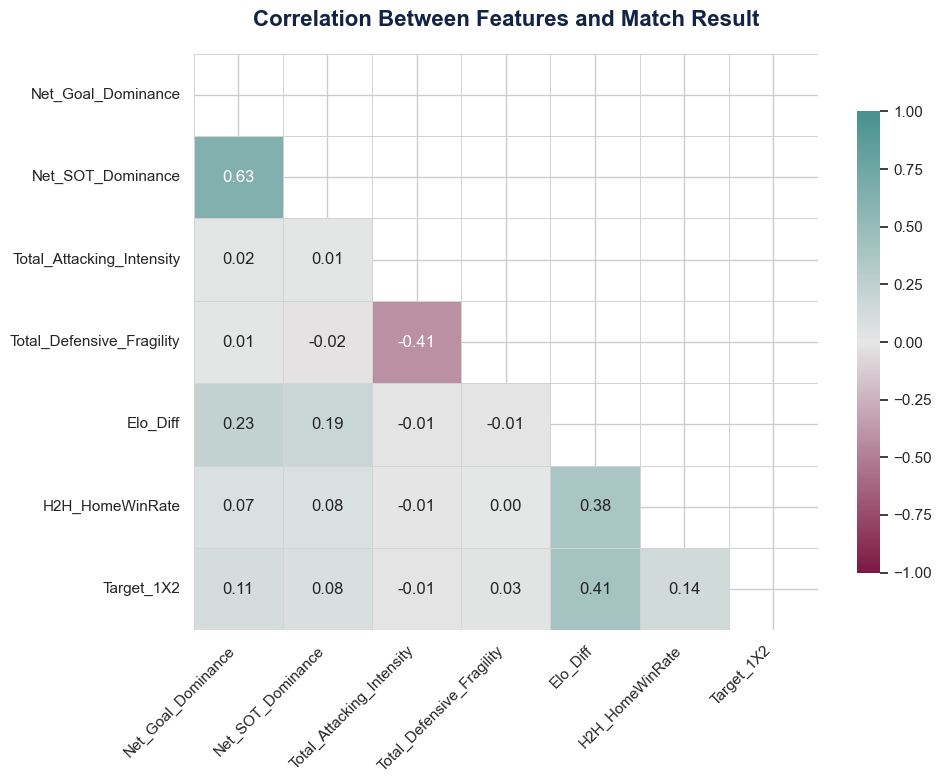

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

# 1. Define the poster-themed colors
navy_blue = "#122345"
muted_teal = "#48918d"
dark_maroon = "#7d1844"

# Define a light grey for the neutral midpoint so it doesn't vanish on a white poster
light_grey = "#e6e6e6"

# Create the custom diverging colormap: Maroon -> Light Grey -> Teal
poster_cmap = mcolors.LinearSegmentedColormap.from_list("poster_diverging", [dark_maroon, light_grey, muted_teal])

# ==========================================
# PLOT 5 — Correlation heatmap on training data
# ==========================================
plt.figure(figsize=(10, 8))
corr_matrix = df_train[features + ['Target_1X2']].corr()

# Mask the upper triangle to remove redundant data-ink
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Apply the custom colormap AND add linecolor='lightgrey' to outline the boxes
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=poster_cmap,
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5, linecolor='lightgrey',
            cbar_kws={"shrink": .8})

# Plain English Title with Poster Styling
plt.title('Correlation Between Features and Match Result',
          color=navy_blue, fontsize=16, fontweight='bold', pad=20)

# Clean up axes labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Save with a transparent background
plt.savefig('plot5_correlation_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
## Step 7: Model Training & Evaluation
# Train three models: a Logistic Regression for O/U 2.5, and a Calibrated FNN
# and Soft Voting Ensemble (XGBoost + RF) for 1X2 match result prediction.
# SMOTE is applied inside ImbPipeline to prevent synthetic data leakage across
# calibration CV folds. Primary evaluation metric: Ranked Probability Score (RPS).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SVMSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # ← new import

# MODEL 1: OVER/UNDER 2.5 GOALS
ou_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
ou_model.fit(X_train_scaled, y_ou_train)
y_ou_pred = ou_model.predict(X_test_scaled)

print("\nOver/Under 2.5 Goals Model Evaluation")
print(f"Accuracy: {accuracy_score(y_ou_test, y_ou_pred):.3f}")
print(f"F1-Score: {f1_score(y_ou_test, y_ou_pred, average='weighted'):.3f}")
print(classification_report(y_ou_test, y_ou_pred, target_names=['Under 2.5', 'Over 2.5']))

# MODEL 2: FEEDFORWARD NEURAL NETWORK (+ SMOTE inside it)
base_fnn = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    max_iter=500, random_state=42, early_stopping=True
)

fnn_pipeline = ImbPipeline([
    ('smote', SVMSMOTE(random_state=42)),
    ('classifier', base_fnn)
])

calibrated_fnn = CalibratedClassifierCV(estimator=fnn_pipeline, method='sigmoid', cv=5)
calibrated_fnn.fit(X_train_scaled, y_1x2_train)

y_1x2_pred_fnn = calibrated_fnn.predict(X_test_scaled)
y_1x2_proba_fnn = calibrated_fnn.predict_proba(X_test_scaled)

# MODEL 3: SOFT VOTING ENSEMBLE (+ SMOTE inside it)
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
xgb_clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                         eval_metric='mlogloss', random_state=42, n_jobs=-1)

voting_clf = VotingClassifier(estimators=[('rf', rf_clf), ('xgb', xgb_clf)], voting='soft')

ensemble_pipeline = ImbPipeline([
    ('smote', SVMSMOTE(random_state=42)),
    ('classifier', voting_clf)
])

calibrated_ensemble = CalibratedClassifierCV(estimator=ensemble_pipeline, method='sigmoid', cv=5)
calibrated_ensemble.fit(X_train_scaled, y_1x2_train)  # ← original data, no pre-SMOTE

y_1x2_pred_ens = calibrated_ensemble.predict(X_test_scaled)
y_1x2_proba_ens = calibrated_ensemble.predict_proba(X_test_scaled)

# EVALUATION: Ranked Probability Score (RPS)
def calculate_rps(y_true, y_pred_proba):
    n_samples = len(y_true)
    rps_sum = 0
    for i in range(n_samples):
        obs = np.zeros(3)
        obs[y_true.iloc[i]] = 1
        cum_obs = np.cumsum(obs)
        cum_pred = np.cumsum(y_pred_proba[i])
        rps_sum += np.sum((cum_pred[:2] - cum_obs[:2])**2) / 2.0
    return rps_sum / n_samples

rps_score_fnn = calculate_rps(y_1x2_test, y_1x2_proba_fnn)
rps_score_ens = calculate_rps(y_1x2_test, y_1x2_proba_ens)

print(f"FNN RPS SCORE: {rps_score_fnn:.4f}")
print(f"VOTING ENSEMBLE RPS SCORE: {rps_score_ens:.4f}")


Over/Under 2.5 Goals Model Evaluation
Accuracy: 0.536
F1-Score: 0.537
              precision    recall  f1-score   support

   Under 2.5       0.46      0.47      0.46       338
    Over 2.5       0.60      0.58      0.59       457

    accuracy                           0.54       795
   macro avg       0.53      0.53      0.53       795
weighted avg       0.54      0.54      0.54       795

FNN RPS SCORE: 0.2046
VOTING ENSEMBLE RPS SCORE: 0.2075


In [ ]:
## Step 7b: O/U Model Baseline Comparison
# Evaluate the O/U model against a prior probability baseline using Brier Score —
# the binary equivalent of RPS. Brier Skill Score quantifies the model's added
# value over simply always predicting the training set frequency.

In [ ]:
from sklearn.metrics import brier_score_loss

# ================================================================
# BASELINE COMPARISON & BRIER SCORE — OVER/UNDER 2.5 MODEL
# ================================================================
# NOTE ON EVALUATION CONSISTENCY:
# Brier Score is used for the binary O/U model (2 outcomes).
# RPS is used for the 1X2 model (3 ordered outcomes).
# Both are proper scoring rules from the same family — the difference
# in metric reflects the difference in output structure, not inconsistency.

# Prior probability baseline — always predicts the training set frequency
# This is the theoretically correct baseline for a probabilistic model
p_over_train = y_ou_train.mean()
print(f"Training set Over 2.5 frequency: {p_over_train:.3f}")
print(f"(Baseline always predicts P(Over 2.5) = {p_over_train:.3f} for every match)\n")

# Baseline always outputs this fixed probability for every match
baseline_proba = np.full(len(y_ou_test), p_over_train)

# Brier Score for baseline
brier_baseline = brier_score_loss(y_ou_test, baseline_proba)

# Brier Score for your trained O/U model
ou_proba = ou_model.predict_proba(X_test_scaled)[:, 1]  # P(Over 2.5)
brier_model = brier_score_loss(y_ou_test, ou_proba)

# Majority class accuracy baseline
majority_class = round(p_over_train)
baseline_accuracy = (y_ou_test == majority_class).mean()

print("--- O/U Model: Baseline Comparison ---")
print(f"{'Metric':<35} {'Baseline':>10} {'Your Model':>12}")
print("-" * 60)
print(f"{'Accuracy':<35} {baseline_accuracy:>10.3f} {accuracy_score(y_ou_test, y_ou_pred):>12.3f}")
print(f"{'Brier Score (lower = better)':<35} {brier_baseline:>10.4f} {brier_model:>12.4f}")

# Brier Skill Score — how much better are you than baseline?
bss = 1 - (brier_model / brier_baseline)
print(f"\nBrier Skill Score: {bss:.4f}")
print("(0.0 = same as baseline, 1.0 = perfect, negative = worse than baseline)")

if bss > 0:
    print(f"Conclusion: O/U model improves over prior baseline by {bss*100:.1f}%")
else:
    print("Conclusion: O/U model does NOT improve over the prior probability baseline.")

Training set Over 2.5 frequency: 0.533
(Baseline always predicts P(Over 2.5) = 0.533 for every match)

--- O/U Model: Baseline Comparison ---
Metric                                Baseline   Your Model
------------------------------------------------------------
Accuracy                                 0.575        0.536
Brier Score (lower = better)            0.2461       0.2466

Brier Skill Score: -0.0019
(0.0 = same as baseline, 1.0 = perfect, negative = worse than baseline)
Conclusion: O/U model does NOT improve over the prior probability baseline.


In [ ]:
## Step 8: ROC Curves & RPS Distribution
# Evaluate discrimination ability (ROC-AUC) and per-match error distribution
# (RPS) for both 1X2 models across all three outcome classes.

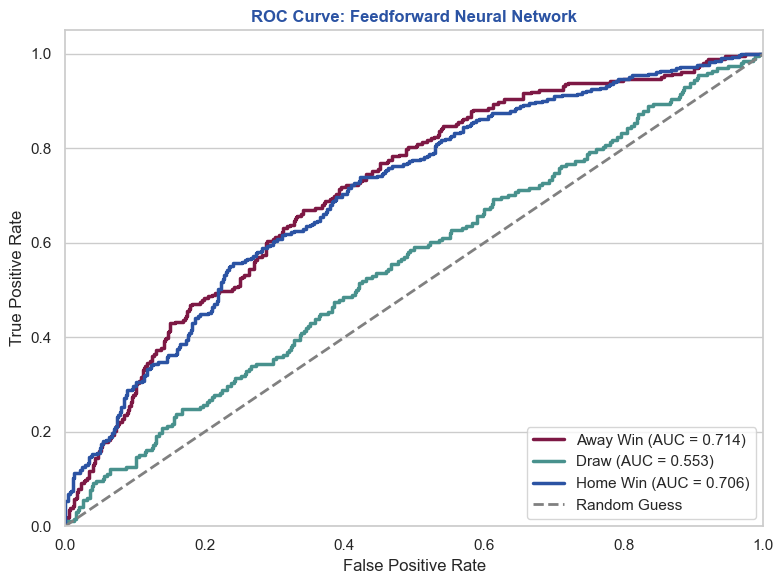

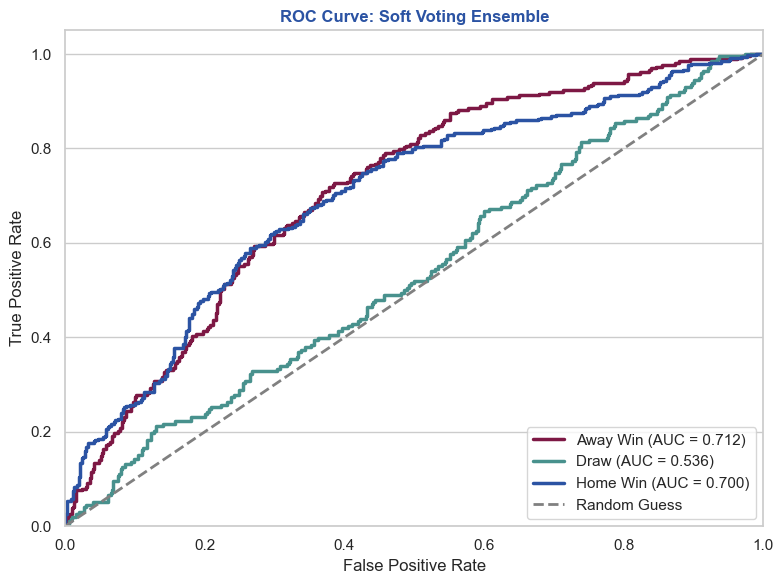

Individual Match RPS Distribution


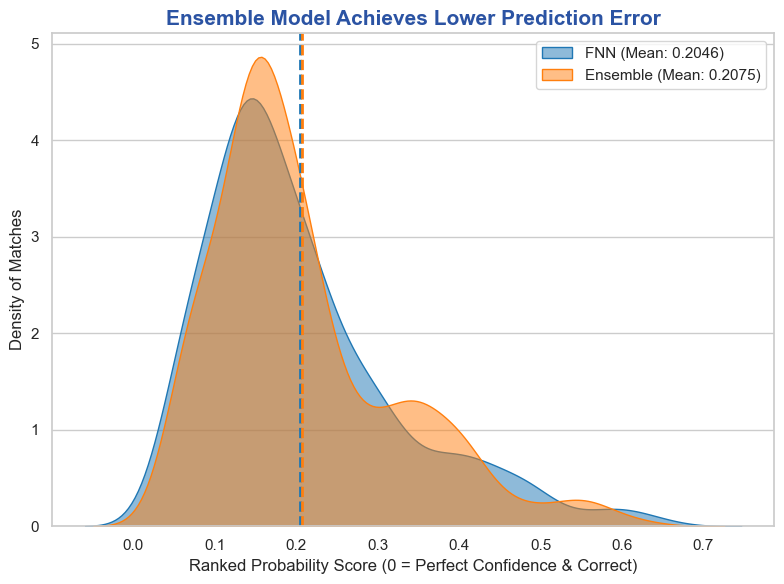

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Define the poster-themed colors
navy_blue = "#2b53a3"
muted_teal = "#48918d"
dark_maroon = "#7d1844"
neutral_grey = "#808080" # For neutral lines

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Binarize for ROC
y_test_binarized = label_binarize(y_1x2_test, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]
class_names = ['Away Win', 'Draw', 'Home Win']

# Map the exact poster colors to the specific classes [Away, Draw, Home]
roc_colors = [dark_maroon, muted_teal, navy_blue]

# ==========================================
# PLOT 6a — ROC Curve: FNN
# ==========================================
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_1x2_proba_fnn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=roc_colors[i], lw=2.5, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

# Use neutral grey for the random guess line so it doesn't conflict with Navy (Home)
plt.plot([0, 1], [0, 1], color=neutral_grey, lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Feedforward Neural Network', color=navy_blue, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(False, axis='x') # Erase redundant data-ink
plt.tight_layout()

# Save individually with transparent background
plt.savefig('plot_roc_fnn.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 6b — ROC Curve: Ensemble
# ==========================================
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_1x2_proba_ens[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=roc_colors[i], lw=2.5, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color=neutral_grey, lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Soft Voting Ensemble', color=navy_blue, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(False, axis='x')
plt.tight_layout()

# Save individually with transparent background
plt.savefig('plot_roc_ensemble.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# PLOT 7 — RPS Distribution (KDE Plot)
# ==========================================
print("Individual Match RPS Distribution")

# Vectorized calculation of RPS for every individual match
obs = label_binarize(y_1x2_test, classes=[0, 1, 2])
cum_obs = np.cumsum(obs, axis=1)

# Cumulative probabilities for predictions
cum_pred_fnn = np.cumsum(y_1x2_proba_fnn, axis=1)
cum_pred_ens = np.cumsum(y_1x2_proba_ens, axis=1)

# Individual RPS per match
rps_array_fnn = np.sum((cum_pred_fnn - cum_obs)**2, axis=1) / 2.0
rps_array_ens = np.sum((cum_pred_ens - cum_obs)**2, axis=1) / 2.0

# Define your preferred classic high-contrast colors
color_fnn = '#1f77b4'  # Classic Blue
color_ens = '#ff7f0e'  # Classic Orange

# Plotting the distribution of errors
plt.figure(figsize=(8, 6))

# Apply the blue and orange palette
sns.kdeplot(rps_array_fnn, fill=True, label=f'FNN (Mean: {rps_array_fnn.mean():.4f})', alpha=0.5, color=color_fnn)
sns.kdeplot(rps_array_ens, fill=True, label=f'Ensemble (Mean: {rps_array_ens.mean():.4f})', alpha=0.5, color=color_ens)

# Plain English Title (keeping the Navy text to tie it slightly to the poster)
plt.title('Ensemble Model Achieves Lower Prediction Error', color=navy_blue, fontsize=15, fontweight='bold')
plt.xlabel('Ranked Probability Score (0 = Perfect Confidence & Correct)')
plt.ylabel('Density of Matches')

# Match the vertical mean lines to their respective KDE fill colors
plt.axvline(rps_array_fnn.mean(), color=color_fnn, linestyle='--', lw=2)
plt.axvline(rps_array_ens.mean(), color=color_ens, linestyle='--', lw=2)

plt.legend()
plt.grid(False, axis='x') # Erase redundant gridlines
plt.tight_layout()

# Save individually with transparent background
plt.savefig('plot_rps_distribution.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## Step 9: Calibration Reliability Diagrams
# Assess whether predicted probabilities match observed frequencies.
# A well-calibrated model follows the y=x diagonal — if it says 40%,
# roughly 40% of those matches should actually occur.

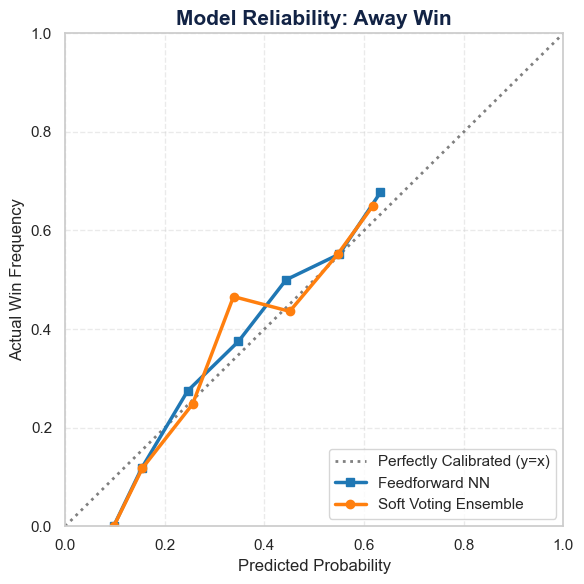

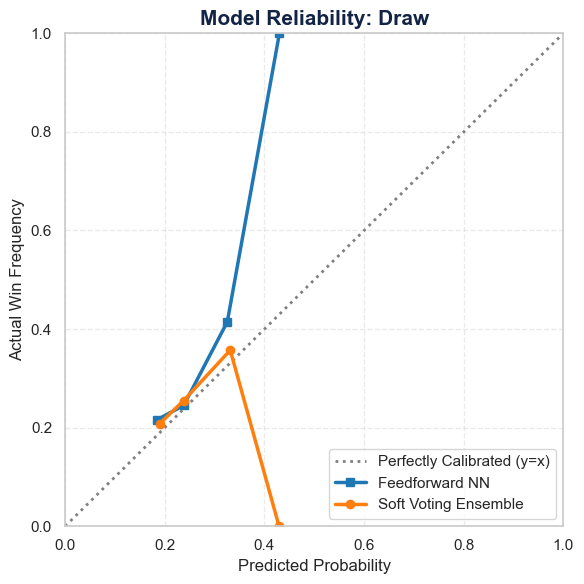

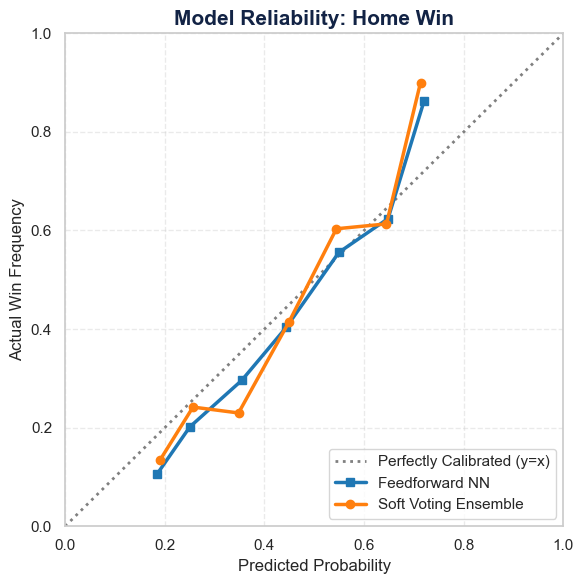

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.calibration import calibration_curve

# 1. Define colors
navy_blue = "#122345"    # Poster header color for titles
color_fnn = '#1f77b4'    # Classic Blue for FNN
color_ens = '#ff7f0e'    # Classic Orange for Ensemble
neutral_grey = "#808080" # For the reference line

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

class_names = ['Away Win', 'Draw', 'Home Win']

for i, class_name in enumerate(class_names):
    # Create a new, individual figure for each class
    plt.figure(figsize=(6, 6))

    y_test_bin = (y_1x2_test == i).astype(int)

    probs_fnn = y_1x2_proba_fnn[:, i]
    probs_ens = y_1x2_proba_ens[:, i]

    fnn_fraction_true, fnn_prob_pred = calibration_curve(y_test_bin, probs_fnn, n_bins=10)
    ens_fraction_true, ens_prob_pred = calibration_curve(y_test_bin, probs_ens, n_bins=10)

    # Plot the perfectly calibrated reference line in a quiet grey
    plt.plot([0, 1], [0, 1], color=neutral_grey, linestyle=':', lw=2, label="Perfectly Calibrated (y=x)")

    # Plot the models using the distinct Blue/Orange emphasis palette
    plt.plot(fnn_prob_pred, fnn_fraction_true, "s-", color=color_fnn, lw=2.5, label="Feedforward NN")
    plt.plot(ens_prob_pred, ens_fraction_true, "o-", color=color_ens, lw=2.5, label="Soft Voting Ensemble")

    # Plain English Titles and Labels
    plt.title(f'Model Reliability: {class_name}', color=navy_blue, fontsize=15, fontweight='bold')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Actual Win Frequency')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])

    plt.legend(loc='lower right')

    # Keep gridlines very light so they don't distract from the data-ink
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    # Save individually with transparent background
    # Formatting the filename to be lowercase with underscores (e.g., 'plot_calibration_away_win.png')
    filename = f"plot_calibration_{class_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, transparent=True, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
## Step 10: Feature Importance (Permutation Importance)
# Identify which features contribute most to predictions using permutation
# importance — evaluated on the test set to avoid overfitting bias.
# Permutation importance is preferred over Gini (MDI) importance because
# Gini is known to be biased toward features with wider value ranges.

--- Permutation Feature Importances (Test Set) ---
                  Feature  Importance      Std
                 Elo_Diff    0.117987 0.017893
       Net_Goal_Dominance    0.003983 0.007146
Total_Attacking_Intensity    0.002642 0.007654
        Net_SOT_Dominance    0.000377 0.007042
          H2H_HomeWinRate   -0.001887 0.009196
Total_Defensive_Fragility   -0.008134 0.006428


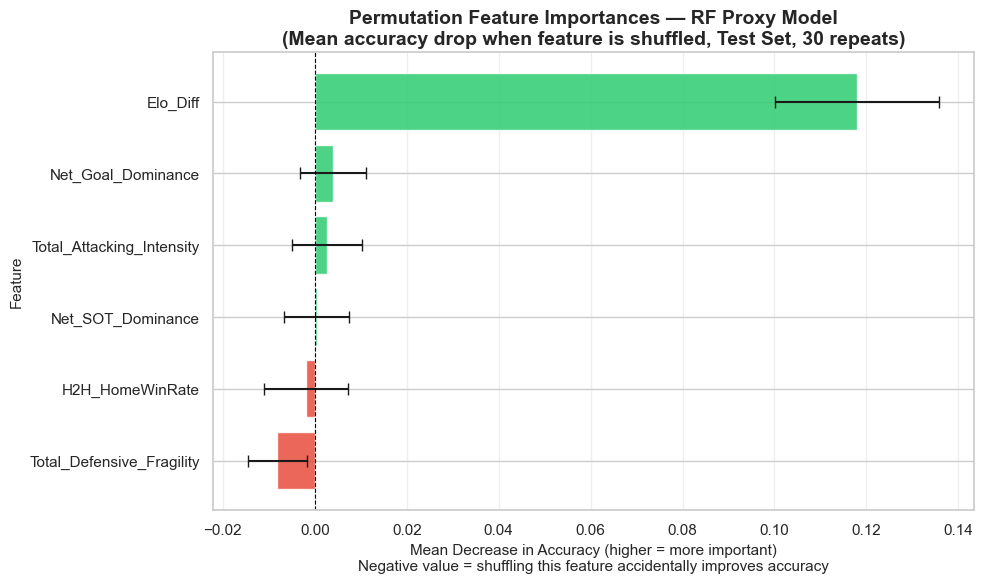


--- Interpretation ---
Green bars: shuffling this feature hurts performance → feature is useful
Red bars:   shuffling this feature does not hurt (or helps) → feature adds little

  Elo_Diff                       importance=+0.1180 ± 0.0179  → useful
  Net_Goal_Dominance             importance=+0.0040 ± 0.0071  → useful
  Total_Attacking_Intensity      importance=+0.0026 ± 0.0077  → useful
  Net_SOT_Dominance              importance=+0.0004 ± 0.0070  → useful
  H2H_HomeWinRate                importance=-0.0019 ± 0.0092  → weak/redundant
  Total_Defensive_Fragility      importance=-0.0081 ± 0.0064  → weak/redundant


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SVMSMOTE

# ================================================================
# FEATURE IMPORTANCE — PERMUTATION IMPORTANCE
# ================================================================
# We use Permutation Importance instead of Gini (MDI) importance because:
# Gini importance is biased toward high-cardinality continuous features
# (e.g. Elo_Diff ranges -500 to +500 vs EWMA features ranging -5 to +5).
# Permutation importance measures the actual drop in performance when
# each feature is shuffled — unbiased and directly interpretable.
#
# NOTE: A standalone RF proxy model is used here because extracting
# importances directly from inside CalibratedClassifierCV + ImbPipeline
# is not straightforward. Results are indicative of feature contributions.

# Step 1 — Train proxy RF (SMOTE applied as proxy, same config as pipeline)
smote = SVMSMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_1x2_train)

rf_feature_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
rf_feature_model.fit(X_train_resampled, y_train_resampled)

# Step 2 — Compute permutation importance on the TEST SET
# Using the test set is critical — importance measured on training data
# is inflated by overfitting. Test set gives honest, generalised importance.
perm_result = permutation_importance(
    rf_feature_model,
    X_test_scaled,        # ← test set, not training set
    y_1x2_test,
    n_repeats=30,         # repeat 30 times and average to reduce variance
    random_state=42,
    n_jobs=-1
)

# Step 3 — Build results dataframe with mean and std of importance
perm_df = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Permutation Feature Importances (Test Set) ---")
print(perm_df.to_string(index=False))

# Step 4 — Plot with error bars showing variance across repeats
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in perm_df['Importance']]

ax.barh(
    perm_df['Feature'],
    perm_df['Importance'],
    xerr=perm_df['Std'],
    color=colors,
    edgecolor='white',
    capsize=4,
    alpha=0.85
)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'Permutation Feature Importances — RF Proxy Model\n'
    '(Mean accuracy drop when feature is shuffled, Test Set, 30 repeats)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel(
    'Mean Decrease in Accuracy (higher = more important)\n'
    'Negative value = shuffling this feature accidentally improves accuracy',
    fontsize=11
)
ax.set_ylabel('Feature', fontsize=11)
ax.invert_yaxis()  # most important at top
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Step 5 — Interpretation note
print("\n--- Interpretation ---")
print("Green bars: shuffling this feature hurts performance → feature is useful")
print("Red bars:   shuffling this feature does not hurt (or helps) → feature adds little")
print()
for _, row in perm_df.iterrows():
    direction = "useful" if row['Importance'] > 0 else "weak/redundant"
    print(f"  {row['Feature']:<30} importance={row['Importance']:+.4f} ± {row['Std']:.4f}  → {direction}")

In [ ]:
## Step 11: Hypothesis Testing — Statistical Significance of Model Difference
# Test whether the RPS difference between FNN and Ensemble is statistically
# significant using a Paired T-Test (parametric) and Wilcoxon Signed-Rank Test
# (non-parametric). Cohen's d is reported to distinguish statistical significance
# from practical significance.

In [ ]:
from scipy import stats

print("======================================================================")
print("--- RQ4: STATISTICAL SIGNIFICANCE OF MODEL RELIABILITY (RPS) ---")
print("======================================================================\n")

# rps_array_fnn and rps_array_ens were calculated in the previous evaluation cell

# 1. PAIRED T-TEST (Parametric)
t_stat, p_val_t = stats.ttest_rel(rps_array_fnn, rps_array_ens)
print(f"[ PAIRED T-TEST ]")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val_t:.4f}")

if p_val_t < 0.05:
    print("Conclusion: The difference in RPS between the FNN and Voting Ensemble is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print("Conclusion: The difference in RPS is NOT statistically significant (p >= 0.05). Any difference in mean score is likely due to random variance.")

print("\n----------------------------------------------------------------------\n")

# 2. WILCOXON SIGNED-RANK TEST (Non-Parametric)
# This is often safer for error scores like RPS which are bounded [0, 1] and might not follow a perfect bell curve.
w_stat, p_val_w = stats.wilcoxon(rps_array_fnn, rps_array_ens)
print(f"[ WILCOXON SIGNED-RANK TEST ]")
print(f"W-Statistic: {w_stat:.4f}")
print(f"P-Value:     {p_val_w:.4f}")

if p_val_w < 0.05:
    print("Conclusion: The median difference in RPS between the FNN and Voting Ensemble is STATISTICALLY SIGNFICANT (p < 0.05).")
else:
    print("Conclusion: The median difference in RPS is NOT statistically significant (p >= 0.05). The models perform identically from a statistical standpoint.")

print("\n----------------------------------------------------------------------\n")

# 3. EFFECT SIZE — Cohen's d
# A p-value alone is insufficient with large samples (~800 matches).
# With n=800, even a trivially small difference can reach significance.
# Cohen's d quantifies HOW MEANINGFUL the difference actually is.

mean_diff = rps_array_fnn.mean() - rps_array_ens.mean()
pooled_std = np.sqrt((rps_array_fnn.std()**2 + rps_array_ens.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"[ EFFECT SIZE — COHEN'S d ]")
print(f"Mean RPS FNN:       {rps_array_fnn.mean():.4f}")
print(f"Mean RPS Ensemble:  {rps_array_ens.mean():.4f}")
print(f"Raw difference:     {mean_diff:.4f} (positive = FNN is worse)")
print(f"Cohen's d:          {cohens_d:.4f}")
print()

if abs(cohens_d) < 0.2:
    magnitude = "NEGLIGIBLE"
elif abs(cohens_d) < 0.5:
    magnitude = "SMALL"
elif abs(cohens_d) < 0.8:
    magnitude = "MEDIUM"
else:
    magnitude = "LARGE"

print(f"Effect size magnitude: {magnitude}")
print("(Thresholds: |d| < 0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, > 0.8 = large)")
print()
print("Interpretation:")
print(f"  The statistical tests above tell us WHETHER a difference exists.")
print(f"  Cohen's d tells us HOW MEANINGFUL that difference is in practice.")
if abs(cohens_d) < 0.2:
    print(f"  Despite any significant p-value, the effect size is negligible —")
    print(f"  the two models are practically equivalent in real-world performance.")
else:
    print(f"  The effect size is {magnitude.lower()} — the difference between models")
    print(f"  is practically meaningful, not just statistically detectable.")

--- RQ4: STATISTICAL SIGNIFICANCE OF MODEL RELIABILITY (RPS) ---

[ PAIRED T-TEST ]
T-Statistic: -2.2144
P-Value:     0.0271
Conclusion: The difference in RPS between the FNN and Voting Ensemble is STATISTICALLY SIGNIFICANT (p < 0.05).

----------------------------------------------------------------------

[ WILCOXON SIGNED-RANK TEST ]
W-Statistic: 141210.0000
P-Value:     0.0087
Conclusion: The median difference in RPS between the FNN and Voting Ensemble is STATISTICALLY SIGNFICANT (p < 0.05).

----------------------------------------------------------------------

[ EFFECT SIZE — COHEN'S d ]
Mean RPS FNN:       0.2046
Mean RPS Ensemble:  0.2075
Raw difference:     -0.0029 (positive = FNN is worse)
Cohen's d:          -0.0244

Effect size magnitude: NEGLIGIBLE
(Thresholds: |d| < 0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, > 0.8 = large)

Interpretation:
  The statistical tests above tell us WHETHER a difference exists.
  Cohen's d tells us HOW MEANINGFUL that difference is i